## Adding torch.nn elements

Make deeper model + use more context

Similar to Wavenet

In [39]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()


In [3]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
vocab_size = len(itos)

In [4]:
import random
random.seed(42)
random.shuffle(words)

In [5]:
block_size = 3 # context length, how many chars we take to predict next

def build_dataset(words):
    X, Y = [], [] # input and labels
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # rolling window, crop and append new
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [40]:
class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0,1)
      xmean = x.mean(dim, keepdim=True) # batch mean
      xvar = x.var(dim, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
class Embedding:
  
  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))
    
  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out
  
  def parameters(self):
    return [self.weight]

# -----------------------------------------------------------------------------------------------
class Flatten:
  
  def __call__(self, x):
    self.out = x.view(x.shape[0], -1)
    return self.out

  def parameters(self):
    return []

class Sequential:

  def __init__(self, layers):
    self.layers = layers
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out

  def parameters(self):
    # get parameters of all layers and put into list
    return [p for layer in self.layers for p in layer.parameters()]

In [6]:
torch.manual_seed(42) # replace generator

In [11]:
n_embd = 10 # dimension of char embedding vector
n_hidden = 200 # n neurons per hidden layer

C = torch.rand((vocab_size, n_embd))
layers = [
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
]

with torch.no_grad():
    layers[-1].weight *= 0.1 # make last layer less confident


parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

12097


In [14]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # new minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix] # X, Y for batch

    # forward pass
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1) # concatenate vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update / GD
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    lossi.append(loss.log10().item())


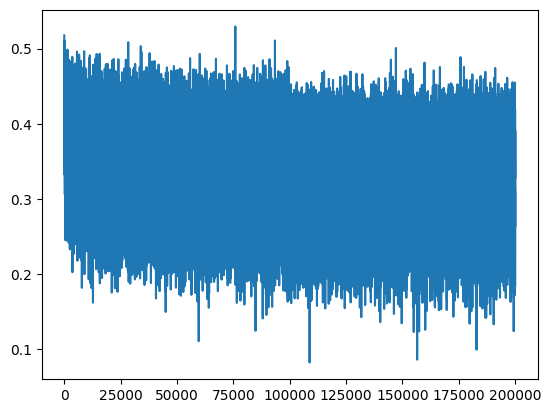

In [15]:
plt.plot(lossi)

In [16]:
# put layers into eval mode (needed for batchnorm)
for layer in layers:
    layer.training = False

In [20]:
@torch.no_grad() # tells torch function below will not require gradients, therefore no need to track it
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    } [split]
    emb = C[x]
    x = emb.view(emb.shape[0], -1) # concatenate vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, y) # loss fcn
    print(split, loss.item())

split_loss('train')
split_loss('val')


train 2.06317138671875
val 2.111293315887451


In [21]:
for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        # forward pass the neural net
        emb = C[torch.tensor([context])]
        x = emb.view(emb.shape[0], -1)
        for layer in layers:
            x = layer(x)
        logits = x
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1).item()
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

lis.
caydnia.
chelle.
raed.
hivaloyntryn.
maddry.
sarah.
dournner.
nilah.
morra.
cau.
emiyee.
yahr.
rosedarith.
briem.
trot.
bariana.
rena.
inna.
khodelynn.


Lets fix plt.plot(lossi)

In [ ]:
# for any array, we can use .view(m, n) to get it into a m x n tensor (cheap)
# either m or n can be -1, in which case torch will automatically infer what it must be
torch.arange(10)
torch.arange(10).view(5, -1)

tensor([[0, 1],
        [2, 3],
        [4, 5],
        [6, 7],
        [8, 9]])

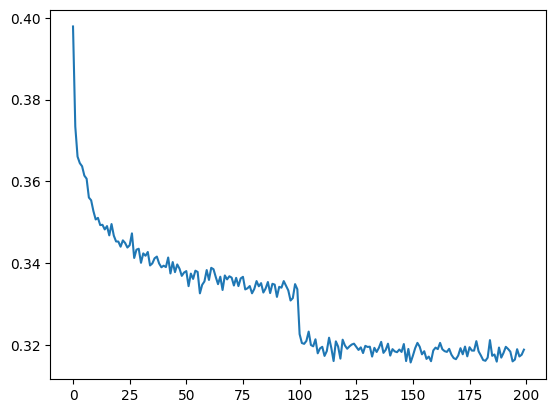

In [ ]:
# turn lossi into a m x 1000 tensor
torch.tensor(lossi).view(-1, 1000)

# calculate mean across column and plot
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In above, the jump around 100 is learning rate decay taking effect

## Forward pass improvement (torchify)
We have added the embedding and flatten classes above to replace C

In [37]:
n_embd = 10 # dimension of char embedding vector
n_hidden = 200 # n neurons per hidden layer

layers = [
    Embedding(vocab_size, n_embd),
    Flatten(),
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
]

with torch.no_grad():
    layers[-1].weight *= 0.1 # make last layer less confident


parameters = [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

    

12097


In [38]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # new minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix] # X, Y for batch

    # forward pass
    x = Xb
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update / GD
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    lossi.append(loss.log10().item())

    break

Now, added sequential class

In [41]:
n_embd = 10 # dimension of char embedding vector
n_hidden = 200 # n neurons per hidden layer

model = Sequential([
    Embedding(vocab_size, n_embd),
    Flatten(),
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    layers[-1].weight *= 0.1 # make last layer less confident


parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

    

12097


In [42]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # new minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix] # X, Y for batch

    # forward pass
    logits = model(Xb) # call model on input to get output logits
    loss = F.cross_entropy(logits, Yb)
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update / GD
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    lossi.append(loss.log10().item())

    break

In [43]:
for layer in model.layers:
    layer.training = False

In [44]:
@torch.no_grad() # tells torch function below will not require gradients, therefore no need to track it
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    } [split]
    logits = model(x)
    loss = F.cross_entropy(logits, y) # loss fcn
    print(split, loss.item())

split_loss('train')
split_loss('val')


train 3.4250941276550293
val 3.424187660217285


In [45]:
for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        # forward pass the neural net
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1).item()
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

smespypkxpmvfiywpmnycffnkoruswset.
zkzqpniddrgeddydffauwhbrjiqotrnxuumtaijdsprupixcqoeiejeyxksxlgswvd.
.
pfixzfxl.
adzguztawanmbvytxdioggyzvinadho.
fhlncfllnrglqhgunpiioal.
uypqrxdeohy.
tkebwtnnchntjzlrmftlpiwb.
somfajhoqpwyl.
uyzcuyofqdonkoefavlnvbpxbccwllrcompyift.
kfzluijhqlfusnjzlniekopk.
ldzabiemqvlnrtqumpuwlxyrcoalsdtqkpciweecncphfxi.
hlhywwqqpi.
.
sutvdqpgmnikeh.
rdujln.
djothcchwpyzrlxudvlpxzqmpocwsikuyfxlbozilyowybnsulleghmzaawvqrgfuv.
hyrrhlriehdtwsowhqhdjnqqcaenkvocjoxmwykmj.
khtarriagibcitgclnswgwcsbptcuktpvnesqbioeqscmygangkguwncilvulseciowhfuf.
ddqg.


## Wavenet

Since training and validation loss are pretty similar, we are likely not overfitting and can improve model by increasing complexity

In [46]:
block_size = 8 # context length, how many chars we take to predict next

def build_dataset(words):
    X, Y = [], [] # input and labels
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # rolling window, crop and append new
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In first compression layer, lets pack every 2 characters together. Currently, our Flatten layer just stretches everything out into 1 list

In [51]:
e = torch.randn(4, 8, 10)
e.view(4, 4, 20).shape

torch.Size([4, 4, 20])

In [52]:
class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0,1)
      xmean = x.mean(dim, keepdim=True) # batch mean
      xvar = x.var(dim, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
class Embedding:
  
  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))
    
  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out
  
  def parameters(self):
    return [self.weight]

# -----------------------------------------------------------------------------------------------
class FlattenConsecutive: # different from torch.nn.flatten
  
  def __init__(self, n):
    self.n = n
  
  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(B, T//self.n, C * self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)
    self.out = x
    return self.out

  def parameters(self):
    return []

class Sequential:

  def __init__(self, layers):
    self.layers = layers
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out

  def parameters(self):
    # get parameters of all layers and put into list
    return [p for layer in self.layers for p in layer.parameters()]

In [56]:
n_embd = 10 # dimension of char embedding vector
n_hidden = 68 # n neurons per hidden layer

model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2),
    Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2),
    Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2),
    Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    layers[-1].weight *= 0.1 # make last layer less confident


parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True


22397


In [48]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # new minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix] # X, Y for batch

    # forward pass
    logits = model(Xb) # call model on input to get output logits
    loss = F.cross_entropy(logits, Yb)
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update / GD
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    lossi.append(loss.log10().item())

    break